In [6]:
import prism
from pathlib import Path
from imagematerials.factory import ModelFactory, Sector
from imagematerials.maintenance import Maintenance, MaintenanceLinear
from imagematerials.concepts import knowledge_graph
from plotting import plot_maintenance_production_comparison, material_colors, maintenance_types, type_colors
import matplotlib.pyplot as plt
import pickle as pkl
import os

from imagematerials.model import (
    GenericMaterials,
    GenericStocks
)
import warnings
from imagematerials.preprocessing import get_preprocessing_data

# Scenario Settings

In [7]:
# Define simulation parameters
time_start = 1920
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(1920, 2100, 1)

scenario_list = {
    'standard_linear': {
        'label': 'Standard Lifetimes & Linear Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'linear'
    },
    'standard_constant': {
        'label': 'Standard Lifetimes & Regular Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'constant'
    },
    'slow_constant': {
        'label': 'Slow Lifetimes & Regular Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'constant'
    },
    'slow_linear': {
        'label': 'Slow Lifetimes & Linear Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'linear'
    }
}

scenario_list2 = {

    'standard_constant': {
        'label': 'Standard Lifetimes & Regular Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'constant'
    },
    'slow_constant': {
        'label': 'Slow Lifetimes & Regular Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'constant'
    },
}

In [8]:
base_dir = Path("..", "..", "image-materials", "data", "raw")
circular_economy_scenario_dirs = {
        "base": base_dir / 'circular_economy_scenarios' / 'base'
    }
climate_policy_scenario_dir = base_dir /'SSP2'

vhc_sector = get_preprocessing_data("vehicles", base_dir, climate_policy_scenario_dir, circular_economy_scenario_dirs,cache = "vhc_sector1.nc")

circular_economy_scenario_dirs_slow = {
        "slow": base_dir / 'circular_economy_scenarios' / 'slow'
    }
climate_policy_scenario_dir_slow = base_dir /  'SSP2'

vhc_sector_slow = get_preprocessing_data("vehicles", base_dir, climate_policy_scenario_dir_slow, circular_economy_scenario_dirs_slow, cache = "vhc_sector_slow1.nc")


In [9]:
all_output = {}

for scen_id, scenario_config in scenario_list.items():   
    pkl_path = f"{scen_id}.pkl"
    if not os.path.exists(pkl_path):
        print(f"\n=== Running Scenario: {scen_id} ===")
        
        # Select the appropriate sector data based on circular economy scenario
        if scenario_config['circular_scen'] == 'standard':
            sector_data = vhc_sector
            print("Using standard sector data")
        elif scenario_config['circular_scen'] == 'slow':
            sector_data = vhc_sector_slow
            print("Using slow circular economy sector data")

        sector_data.all_data["cap_at_lifetime"]=False
        
        # Create factory with appropriate sector data
        factory = ModelFactory(
            sector_data, complete_timeline
        ).add(GenericStocks
        ).add(GenericMaterials)
        
        # Add the appropriate maintenance model based on maintenance scenario
        if scenario_config['maintenance_scen'] == 'constant':
            factory = factory.add(Maintenance)
            print("Using constant maintenance model")
        elif scenario_config['maintenance_scen'] == 'linear':
            # Pass vehicle_lifetimes as an explicit parameter to MaintenanceLinear
            factory = factory.add(MaintenanceLinear)
            print("Using linear maintenance model with explicit vehicle lifetimes")
        
        # Finish model creation
        model = factory.finish()
        
        # Run simulation
        
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            model.simulate(simulation_timeline)
        
        # Store results
        all_output[scen_id] = {
            'model': model,
            'inflow_maintenance': model.inflow_maintenance.to_array(),
            'circular_scenario': scenario_config['circular_scen'],
            'maintenance_scenario': scenario_config['maintenance_scen'],
            'label': scenario_config['label']
        }
        
        print(f"✓ Completed: {scen_id}")
        all_output[scen_id]["model"].save_pkl(pkl_path)
        print(f"\n=== All {len(all_output)} scenarios completed successfully ===")
    else:
        with open(pkl_path, "rb") as handle:
            model = pkl.load(handle)

                # Store results in the same format as when we calculate it
        all_output[scen_id] = {
            'model': model['vehicles'],
            'inflow_maintenance': model['vehicles']['inflow_maintenance'].to_array(),
            'circular_scenario': scenario_config['circular_scen'],
            'maintenance_scenario': scenario_config['maintenance_scen'],
            'label': scenario_config['label']
        }
        print(f"✓ Loaded: {scen_id}")


print("Available scenarios:", list(all_output.keys()))



=== Running Scenario: standard_linear ===
Using standard sector data
Initialized MaintenanceLinear with 47 maintenance types
Using linear maintenance model with explicit vehicle lifetimes
✓ Completed: standard_linear

=== All 1 scenarios completed successfully ===

=== Running Scenario: standard_constant ===
Using standard sector data
Using constant maintenance model
✓ Completed: standard_constant

=== All 2 scenarios completed successfully ===

=== Running Scenario: slow_constant ===
Using slow circular economy sector data
Using constant maintenance model
✓ Completed: slow_constant

=== All 3 scenarios completed successfully ===

=== Running Scenario: slow_linear ===
Using slow circular economy sector data
Initialized MaintenanceLinear with 47 maintenance types
Using linear maintenance model with explicit vehicle lifetimes
✓ Completed: slow_linear

=== All 4 scenarios completed successfully ===
Available scenarios: ['standard_linear', 'standard_constant', 'slow_constant', 'slow_linea

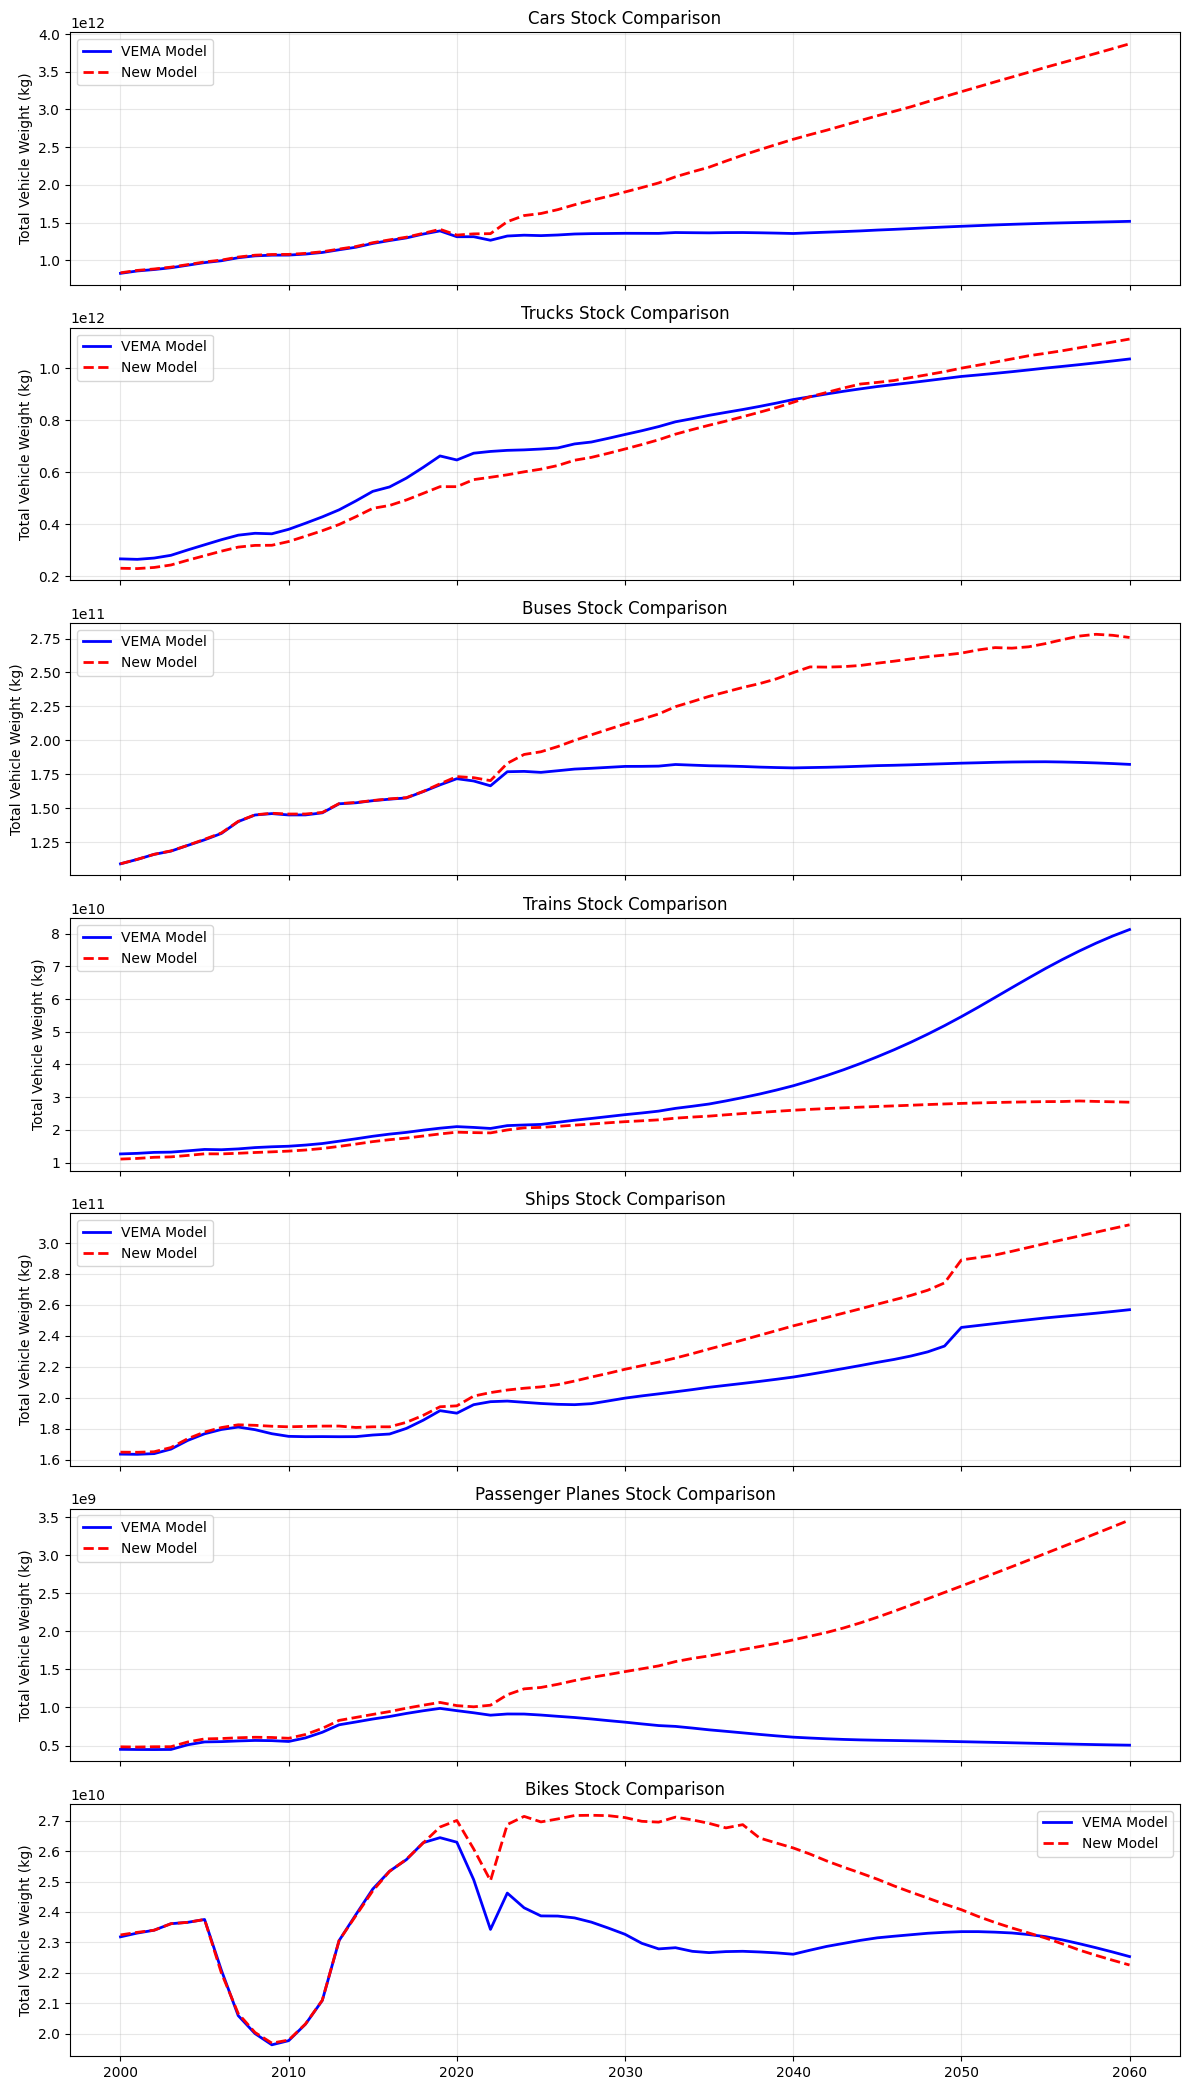


Comparison between VEMA and New Model:
Year    Vehicle Type   VEMA Model     New Model      Difference  % Diff    
----------------------------------------------------------------------
2000    Cars           8.26e+11       8.33e+11       7.20e+09    0.9       %
2000    Trucks         2.66e+11       2.30e+11       -3.62e+10   -13.6     %
2000    Buses          1.09e+11       1.09e+11       4.59e+07    0.0       %
2000    Trains         1.26e+10       1.11e+10       -1.57e+09   -12.4     %
2000    Ships          1.64e+11       1.65e+11       1.27e+09    0.8       %
2000    Passenger Planes4.50e+08       4.83e+08       3.32e+07    7.4       %
2000    Bikes          2.32e+10       2.32e+10       6.24e+07    0.3       %
----------------------------------------------------------------------
2020    Cars           1.31e+12       1.33e+12       2.19e+10    1.7       %
2020    Trucks         6.47e+11       5.44e+11       -1.03e+11   -15.9     %
2020    Buses          1.72e+11       1.73e+11  

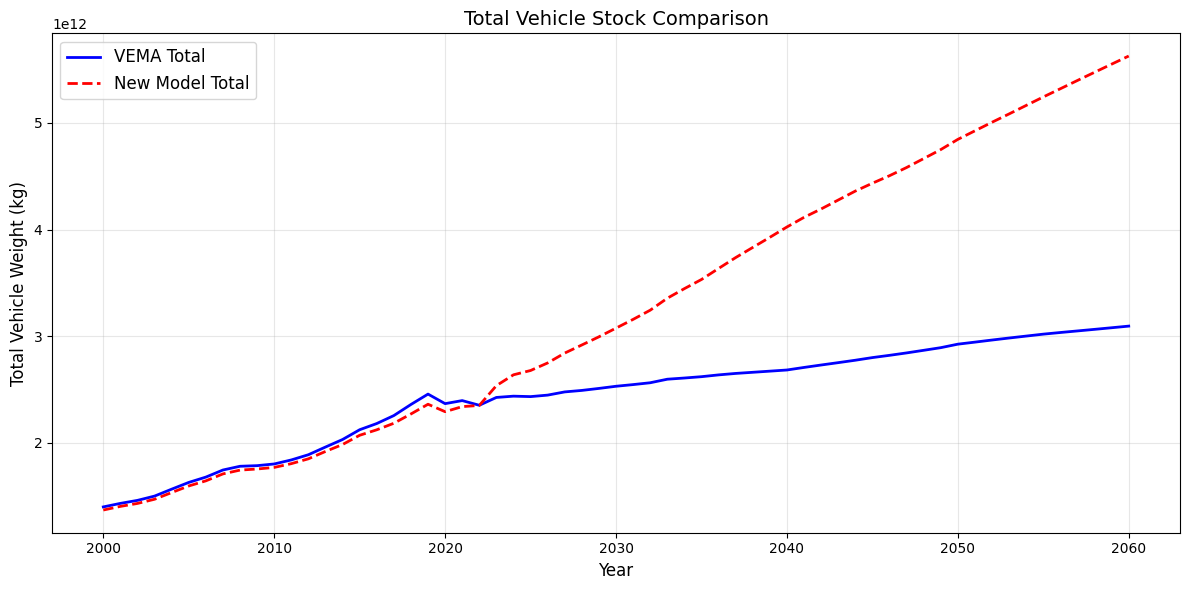

In [10]:
#all_output['standard_constant']['model'].stocks
import pandas as pd
import numpy as np

comparison_types = ["Cars","Trucks","Buses","Trains","Ships","Passenger Planes","Bikes"]


old_stock = pd.read_csv("VEMA_vehicle_stock.csv", index_col=0).T
old_stock.index = old_stock.index.astype(int)
old_stock = old_stock.rename(columns={'Planes': 'Passenger Planes','Bicycles': 'Bikes'})

new_stock_all = all_output["slow_constant"]["model"].stock_by_cohort_materials.sum(dim=["Region","material"])
new_stock_df = knowledge_graph.aggregate_sum(new_stock_all, output_coords=comparison_types, dim="Type").to_pandas().T

start_year = 2000
end_year = 2060

old_stock_filtered = old_stock.loc[start_year:end_year] 
new_stock_filtered = new_stock_df.loc[start_year:end_year] 

common_columns = [col for col in comparison_types if col in old_stock_filtered.columns]
old_stock_filtered = old_stock_filtered[common_columns]
new_stock_filtered = new_stock_filtered[common_columns]

fig, axs = plt.subplots(len(comparison_types), 1, figsize=(12, 3*len(comparison_types)), sharex=True)

for i, vehicle_type in enumerate(comparison_types):
    ax = axs[i]
    
    # Plot old stock if the vehicle type exists in old_stock
    if vehicle_type in old_stock_filtered.columns:
        ax.plot(old_stock_filtered.index, old_stock_filtered[vehicle_type], 
                'b-', label='VEMA Model', linewidth=2)
    
    # Plot new stock
    ax.plot(new_stock_filtered.index, new_stock_filtered[vehicle_type], 
            'r--', label='New Model', linewidth=2)
    
    ax.set_title(f'{vehicle_type} Stock Comparison')
    ax.set_ylabel("Total Vehicle Weight (kg)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 5. Calculate percentage differences and create a summary table
print("\nComparison between VEMA and New Model:")
print("="*70)
print(f"{'Year':<8}{'Vehicle Type':<15}{'VEMA Model':<15}{'New Model':<15}{'Difference':<12}{'% Diff':<10}")
print("-"*70)

sample_years = [2000, 2020,2040,  2060]
sample_years = [y for y in sample_years if y in old_stock_filtered.index and y in new_stock_filtered.index]

for year in sample_years:
    for vehicle_type in comparison_types:
        if vehicle_type in old_stock_filtered.columns:
            old_val = old_stock_filtered.loc[year, vehicle_type] if year in old_stock_filtered.index else np.nan
            new_val = new_stock_filtered.loc[year, vehicle_type] if year in new_stock_filtered.index else np.nan
            
            if not np.isnan(old_val) and not np.isnan(new_val):
                diff = new_val - old_val
                pct_diff = (diff / old_val) * 100 if old_val != 0 else np.nan
                
                print(f"{year:<8}{vehicle_type:<15}{old_val:<15.2e}{new_val:<15.2e}{diff:<12.2e}{pct_diff:<10.1f}%")
    
    print("-"*70)

# 6. Plot total vehicle stock comparison
old_total = old_stock_filtered.sum(axis=1) if not old_stock_filtered.empty else pd.Series()
new_total = new_stock_filtered.sum(axis=1)

plt.figure(figsize=(12, 6))
if not old_total.empty:
    plt.plot(old_total.index, old_total, 'b-', label='VEMA Total', linewidth=2)
plt.plot(new_total.index, new_total, 'r--', label='New Model Total', linewidth=2)

plt.title('Total Vehicle Stock Comparison', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel("Total Vehicle Weight (kg)", fontsize=12)
ax.set_yscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [11]:
old_stock = pd.read_csv("VEMA_vehicle_stock.csv", index_col=0).T
old_stock.index = old_stock.index.astype(int)
old_stock

elements,Bicycles,Cars,Planes,Trains,Buses,Rail Cargo,Air Cargo,Trucks,Ships
2000,2.318354e+10,8.255608e+11,4.497906e+08,1.264784e+10,1.089315e+11,1.279118e+11,3.387493e+08,2.664625e+11,1.636799e+11
2001,2.330765e+10,8.570656e+11,4.477488e+08,1.282451e+10,1.121979e+11,1.264213e+11,3.431265e+08,2.645896e+11,1.635553e+11
2002,2.340136e+10,8.757858e+11,4.470347e+08,1.312236e+10,1.159008e+11,1.257124e+11,3.479829e+08,2.695443e+11,1.639970e+11
2003,2.361490e+10,8.997808e+11,4.481335e+08,1.319749e+10,1.183006e+11,1.264552e+11,3.542867e+08,2.801231e+11,1.669079e+11
2004,2.366055e+10,9.334327e+11,5.097392e+08,1.359443e+10,1.225226e+11,1.287601e+11,4.026447e+08,3.008997e+11,1.725388e+11
...,...,...,...,...,...,...,...,...,...
2056,2.308415e+10,1.495260e+12,5.212068e+08,7.208124e+10,1.840018e+11,2.944330e+11,7.458036e+08,1.007402e+12,2.526522e+11
2057,2.296026e+10,1.500136e+12,5.163733e+08,7.466633e+10,1.837110e+11,2.963891e+11,7.422651e+08,1.014088e+12,2.536330e+11
2058,2.282629e+10,1.504976e+12,5.119163e+08,7.707733e+10,1.833281e+11,2.983349e+11,7.389851e+08,1.021101e+12,2.546752e+11
2059,2.268458e+10,1.510093e+12,5.079751e+08,7.928641e+10,1.828468e+11,3.003185e+11,7.360363e+08,1.028416e+12,2.557812e+11


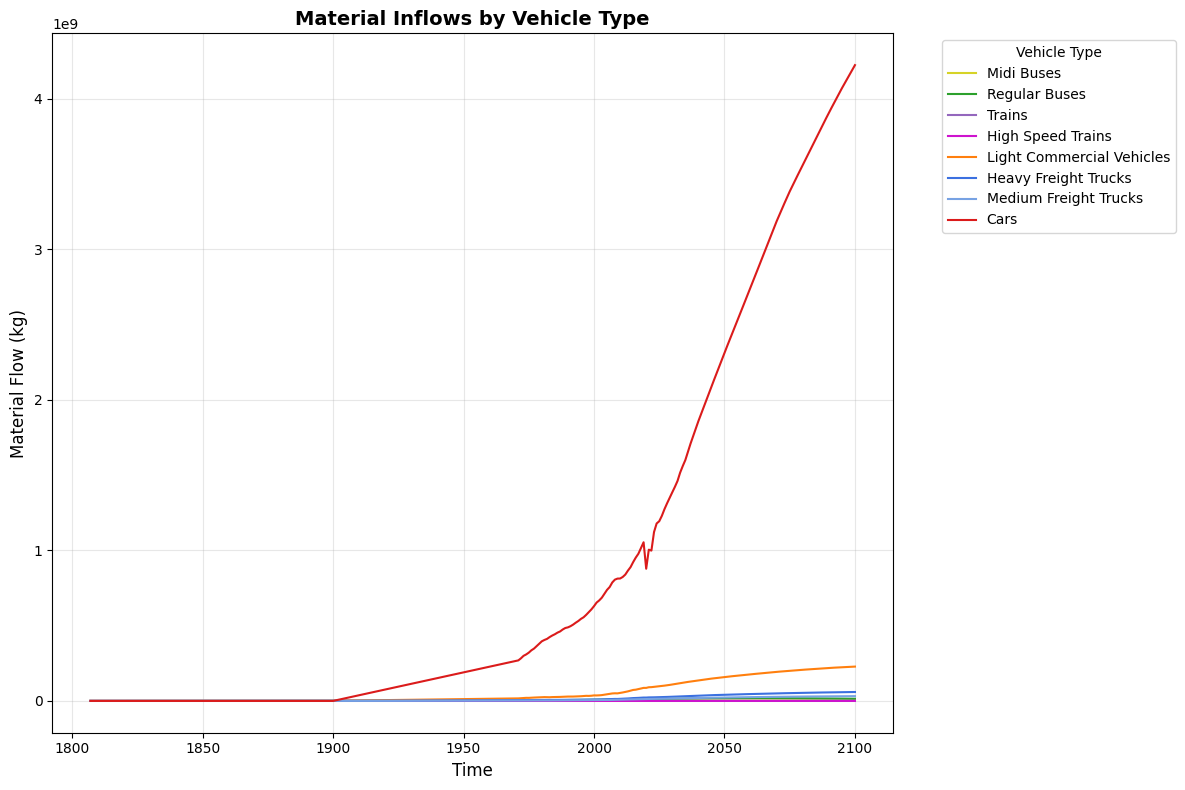

In [12]:
types = [
    "Midi Buses",
    "Regular Buses", 
    "Trains",
    "High Speed Trains",
    "Light Commercial Vehicles",
    "Heavy Freight Trucks", "Medium Freight Trucks",
    "Cars"
]

materials = all_output["standard_constant"]["model"].stocks.sum(dim=["Region"])
rebroadcast_materials = knowledge_graph.aggregate_sum(materials, output_coords=types, dim="Type")


# Create a figure first
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each vehicle type separately with explicit dimensions
for vehicle_type in rebroadcast_materials.coords["Type"].values:
    color = type_colors.get(vehicle_type, '#333333')  # Default to dark gray if not found
    data_for_type = rebroadcast_materials.sel(Type=vehicle_type)
    data_for_type.plot.line(ax=ax, label=vehicle_type, color=color)

# Customize plot appearance
ax.set_title('Material Inflows by Vehicle Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Material Flow (kg)', fontsize=12)
ax.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\indexing.py:1522: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value
c:\Users\5982758\repos\image-materials\scripts\plotting.py:352: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df_full = prod_df_full.fillna(method='bfill').fillna(method='ffill')  # Fill NaNs from rolling window
c:\Users\5982758\AppData\Local\anaconda3\envs\material

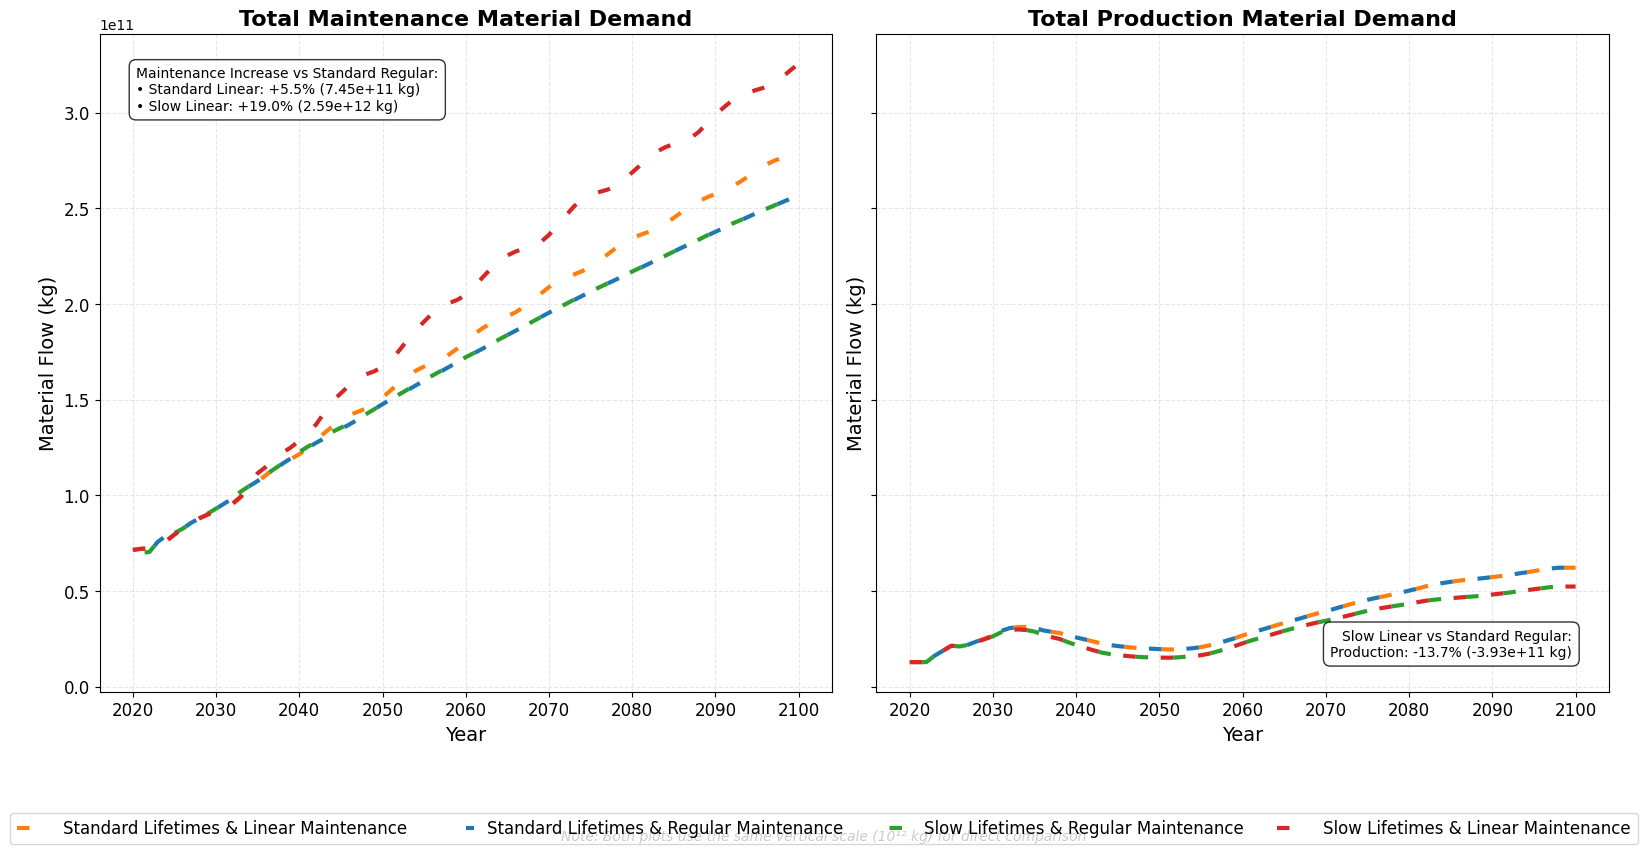


=== Summary Statistics (2050) ===
Standard Lifetimes & Linear Maintenance:
  Maintenance (2050): 1.51e+11 kg
  Production (2050): 1.23e+12 kg
  M/P Ratio: 0.123


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of 

Standard Lifetimes & Regular Maintenance:
  Maintenance (2050): 1.48e+11 kg
  Production (2050): 1.23e+12 kg
  M/P Ratio: 0.120
Slow Lifetimes & Regular Maintenance:
  Maintenance (2050): 1.48e+11 kg
  Production (2050): 1.50e+12 kg
  M/P Ratio: 0.099
Slow Lifetimes & Linear Maintenance:
  Maintenance (2050): 1.67e+11 kg
  Production (2050): 1.50e+12 kg
  M/P Ratio: 0.112


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


In [13]:
plot_maintenance_production_comparison(all_output, year_range=(2020, 2100))


Processing scenario: standard_linear


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


maintenance - Data shape: (181, 4)
maintenance - Data columns: ['Buses', 'Trains', 'Cars', 'Trucks']
production - Data shape: (181, 4)
production - Data columns: ['Buses', 'Trains', 'Cars', 'Trucks']

Processing scenario: standard_constant


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


maintenance - Data shape: (181, 4)
maintenance - Data columns: ['Buses', 'Trains', 'Cars', 'Trucks']
production - Data shape: (181, 4)
production - Data columns: ['Buses', 'Trains', 'Cars', 'Trucks']

Processing scenario: slow_constant


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


maintenance - Data shape: (181, 4)
maintenance - Data columns: ['Buses', 'Trains', 'Cars', 'Trucks']
production - Data shape: (181, 4)
production - Data columns: ['Buses', 'Trains', 'Cars', 'Trucks']

Processing scenario: slow_linear


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


maintenance - Data shape: (181, 4)
maintenance - Data columns: ['Buses', 'Trains', 'Cars', 'Trucks']
production - Data shape: (181, 4)
production - Data columns: ['Buses', 'Trains', 'Cars', 'Trucks']


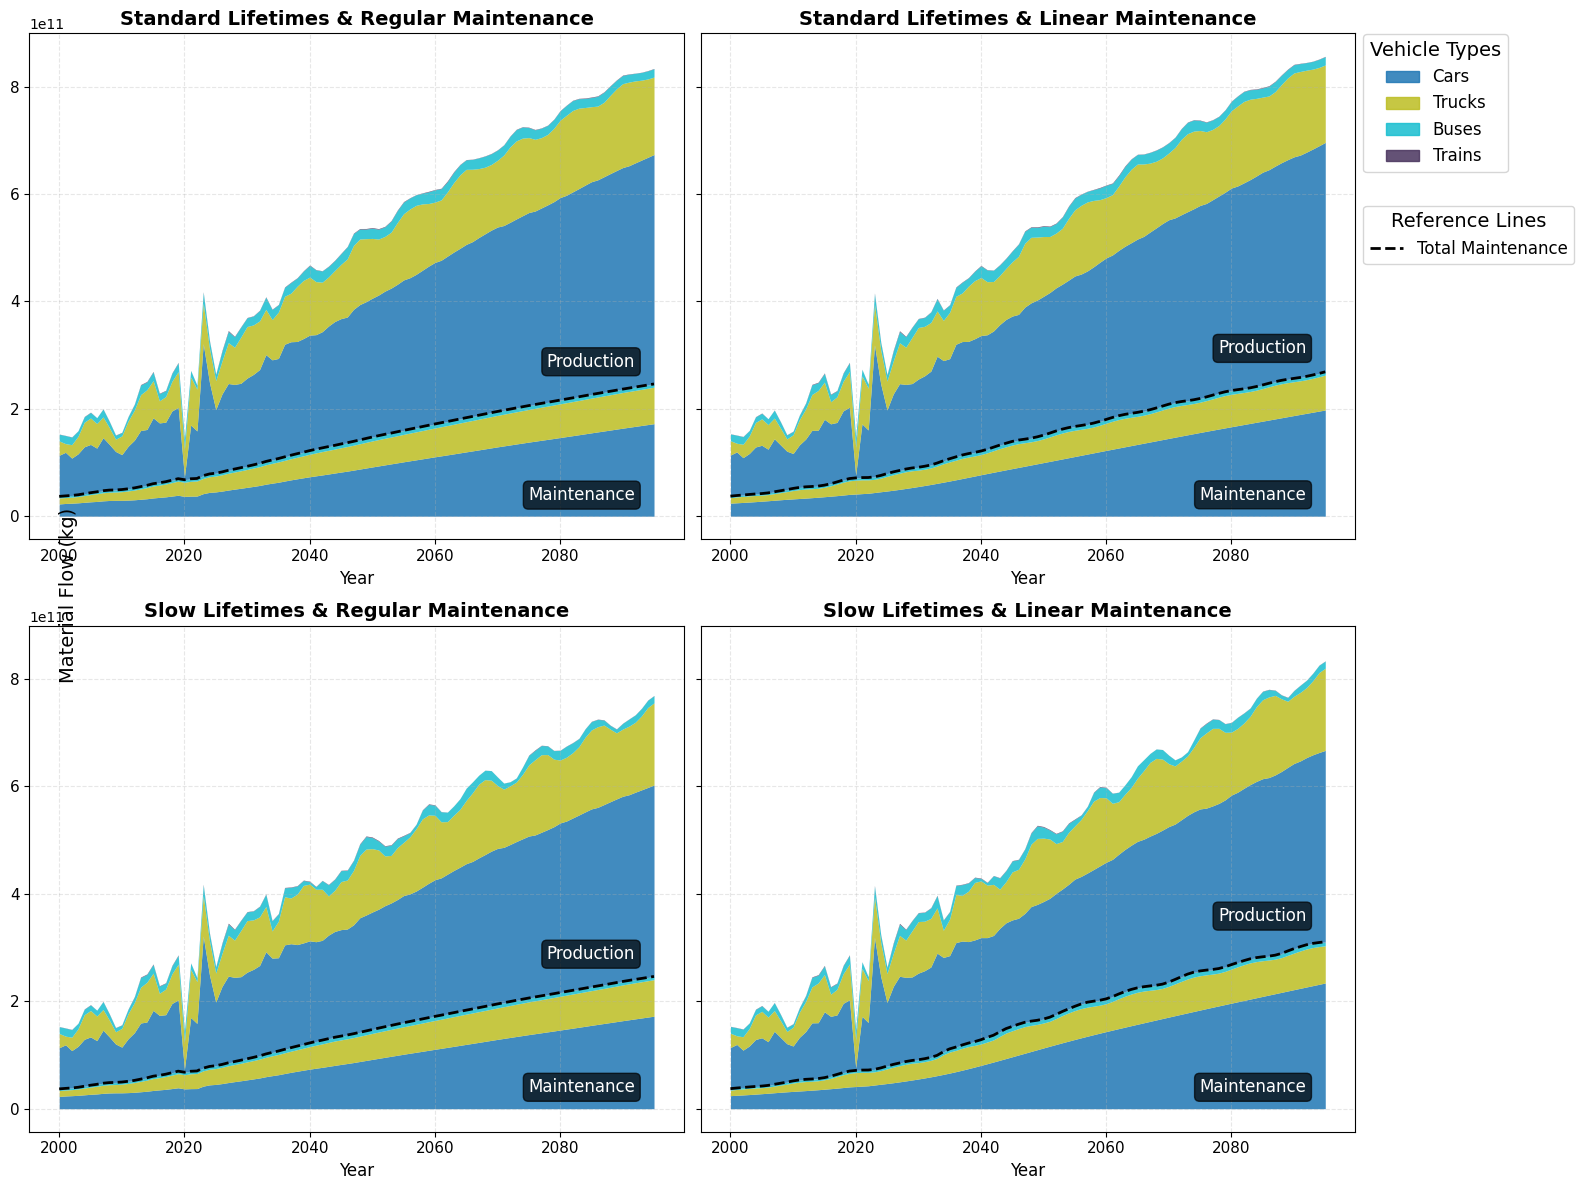

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from imagematerials.concepts import knowledge_graph

"""
Create 2x2 subplot showing maintenance + production for all four scenarios
with vehicle types stacked and uniform coloring across plots.
"""

# Define vehicle type colors (customize as needed)
type_colors = {
    "Cars": "#1f77b4",
    "Light Commercial Vehicles": "#ff7f0e",
    "Regular Buses": "#2ca02c",
    "Midi Buses": "#d62728",
    "Trains": "#49345e",
    "High Speed Trains": "#8c564b",
    "Medium Freight Trucks": "#e377c2",
    "Heavy Freight Trucks": "#7f7f7f",
    "Trucks": "#bcbd22",
    "Buses": "#17becf",
}

maintenance_types = [
    "Buses",
    "Trains",
    "Cars",
    "Trucks",
]

# Helper function to process data for each scenario (modified for vehicle types)
def process_scenario_data_by_type(scenario_data):
    # Get maintenance and production data, sum over Region and material (keep Type)
    maint_data = scenario_data['inflow_maintenance']
    prod_data = scenario_data["model"].inflow_materials.to_array()

    # Aggregate by vehicle types and sum over regions and materials
    maint_data = knowledge_graph.aggregate_sum(maint_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'material'])
    prod_data = knowledge_graph.aggregate_sum(prod_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'material'])

    # Convert to pandas DataFrames
    maint_df = maint_data.to_pandas().T
    prod_df = prod_data.to_pandas().T 
    #prod_df = prod_df.rolling(window=5, center=True).mean()
    
    # Process both dataframes
    for df, name in [(maint_df, 'maintenance'), (prod_df, 'production')]:
        if df is None:
            continue
            
        print(f"{name} - Data shape: {df.shape}")
        print(f"{name} - Data columns: {df.columns.tolist()}")
        

        
        # Keep only non-zero vehicle types
        valid_types = (df != 0).any(axis=0)
        df = df.loc[:, valid_types]
    
    # Update the original dataframes
    if prod_df is not None:
        # Ensure both have same columns for consistent plotting
        all_types = set(maint_df.columns) | set(prod_df.columns)
        for vtype in all_types:
            if vtype not in maint_df.columns:
                maint_df[vtype] = 0
            if vtype not in prod_df.columns:
                prod_df[vtype] = 0
        
        # Sort columns by total sum (maintenance + production)
        total_types = maint_df + prod_df
        sorted_cols = total_types.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
        prod_df = prod_df[sorted_cols]
    else:
        # Sort maintenance only
        sorted_cols = maint_df.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
    
    return maint_df, prod_df

# Process all scenarios
processed_data_by_type = {}
for scen_id, scen_data in all_output.items():
    print(f"\nProcessing scenario: {scen_id}")
    maint_df, prod_df = process_scenario_data_by_type(scen_data)
    if not maint_df.empty:
        processed_data_by_type[scen_id] = {'maintenance': maint_df, 'production': prod_df}

# Get all unique vehicle types across scenarios for consistent coloring
all_types = set()
for scen_data in processed_data_by_type.values():
    all_types.update(scen_data['maintenance'].columns)
    if scen_data['production'] is not None:
        all_types.update(scen_data['production'].columns)

# Update type colors to include any missing vehicle types
for vtype in all_types:
    if vtype not in type_colors:
        type_colors[vtype] = '#999999'  # Default gray

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each scenario
scenario_order = ['standard_constant', 'standard_linear', 'slow_constant', 'slow_linear']

for i, scen_id in enumerate(scenario_order):
    ax = axes[i]
    
    if scen_id not in processed_data_by_type:
        ax.text(0.5, 0.5, f"No data for\n{scen_id}", 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{scen_id} (No Data)", fontsize=14)
        continue
        
    maint_df = processed_data_by_type[scen_id]['maintenance']
    prod_df = processed_data_by_type[scen_id]['production']

    maint_df = maint_df[(maint_df.index >= 2000) & (maint_df.index <= 2095)]
    prod_df = prod_df[(prod_df.index >= 2000) & (prod_df.index <= 2095)]
    
    # Plot maintenance (bottom layer)
    colors_list = [type_colors.get(vtype, '#999999') for vtype in maint_df.columns]
    maint_df.plot.area(
        ax=ax, 
        stacked=True, 
        color=colors_list,
        alpha=0.85, 
        linewidth=0
    )
    ax.get_legend().remove()
    
    # Plot production stacked above maintenance
    if prod_df is not None:
        maintenance_total = maint_df.sum(axis=1)
        prod_bottom = maintenance_total.copy()
        
        for vtype in prod_df.columns:
            if vtype in prod_df.columns and not prod_df[vtype].isna().all():
                top = prod_bottom + prod_df[vtype]
                ax.fill_between(
                    prod_df.index,
                    prod_bottom,
                    top,
                    color=type_colors.get(vtype, '#999999'),
                    alpha=0.85,
                    linewidth=0
                )
                prod_bottom = top
        
        # Plot total maintenance line
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    else:
        # Just maintenance
        maintenance_total = maint_df.sum(axis=1)
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    
    # Styling
    scenario_info = all_output[scen_id]
    title = scenario_info['label']
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Year", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(visible=True, linestyle="--", alpha=0.3)
    
    # Add labels
    if len(maintenance_total) > 0:
        # Maintenance label
        ax.text(
            maintenance_total.index[-1] - 3,
            ax.get_ylim()[0] + 0.07 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            "Maintenance",
            color="white", fontsize=12, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
        )
        
        # Production label (if exists)
        if prod_df is not None:
            ax.text(
                maintenance_total.index[-1] - 3,
                maintenance_total.iloc[-1] * 1.1,
                "Production",
                color="white", fontsize=12, ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
            )

# Add shared Y label
fig.text(0.04, 0.5, 'Material Flow (kg)', va='center', rotation='vertical', fontsize=14)

# Create shared legend for vehicle types
if processed_data_by_type:
    # Get vehicle types from the first scenario for legend order
    first_scenario = list(processed_data_by_type.values())[0]
    legend_types = first_scenario['maintenance'].columns.tolist()
    
    # Create legend handles
    legend_handles = [mpatches.Rectangle((0,0),1,1, color=type_colors[vtype], alpha=0.85) 
                        for vtype in legend_types]
    
    # Add vehicle types legend
    fig.legend(
        legend_handles, 
        legend_types,
        title="Vehicle Types", 
        bbox_to_anchor=(0.85, 0.91), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )
    
    # Add reference line legend
    ref_handles = [plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--')]
    ref_labels = ["Total Maintenance"]
    
    fig.legend(
        ref_handles, 
        ref_labels,
        title="Reference Lines", 
        bbox_to_anchor=(0.85, 0.8), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legends
plt.show()